# Resource Analysis: Inference Cost 

In [113]:
import numpyro
numpyro.set_host_device_count(4)

import sys, pickle, time
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import jax
import torch
from torch.distributions import MultivariateNormal
from sbi.utils import process_prior, BoxUniform
from sbi.inference import SNPE
from sbi.neural_nets import posterior_nn

from hx_models.inference import (
    K_CATEGORICAL4,
    PRIOR_LOG_BETA_F_MEAN, PRIOR_LOG_BETA_F_STD,
    PRIOR_LOG_BETA_L_MEAN, PRIOR_LOG_BETA_L_STD,
    PRIOR_LOG_LAMBDA_MEAN, PRIOR_LOG_LAMBDA_STD,
    do_inference, flat_to_mcmc_obs,
    simulation_wrapper_sbi_extended,
    compute_summary_statistics, latent_to_params_extended,
)

np.random.seed(42)
torch.manual_seed(42)

# ── constants ──────────────────────────────────────────────────────────────
SCENARIO_KEY      = "scenario_2_batch_shutdown"
TRUE_Z_MODE       = 1         # fouling
TRUE_TAU          = 18.0
T                 = 100
K                 = K_CATEGORICAL4
NUM_CHAINS        = 4
ACC_TARGET        = 0.95
N_EVAL            = 20        # observations used in accuracy sweeps
SBI_POST_SAMP     = 1_000     # posterior draws per SBI inference call

# Representative single observation for the τ convergence plot.
# Obs 227: MCMC final median=18.0, SBI final median=18.8 — both land near truth.
REPRESENTATIVE_OBS = 227

SBI_EPOCHS        = 200
SBI_HIDDEN        = 128
SBI_TRANSFORMS    = 5
N_SBI_TRAIN_MAX   = 50_000    

# ── paths ──────────────────────────────────────────────────────────────────
results_dir       = Path("../results")
mcmc_sweep_cache  = results_dir / "mcmc_sweep_scenario2.pkl"
sbi_train_cache   = results_dir / "sbi_sweep_training_data.npz"
sbi_sweep_cache   = results_dir / "sbi_sweep_scenario2.pkl"

print(f"JAX devices: {jax.local_device_count()}")
print(f"Representative observation index: {REPRESENTATIVE_OBS} (true τ={TRUE_TAU})")

JAX devices: 4
Representative observation index: 227 (true τ=18.0)


In [114]:
# ── Load scenario 2 observations ───────────────────────────────────────────
obs_data      = np.load("../data/observations.npz")
scenario2_obs = obs_data[SCENARIO_KEY]   # (500, 700) — 7 channels × T=100 flattened
eval_obs      = scenario2_obs[:N_EVAL]

print(f"Loaded {scenario2_obs.shape[0]} observations, using first {N_EVAL} for sweeps")

Loaded 500 observations, using first 20 for sweeps


## MCMC Accuracy & Timing Sweep

Sweep over `(num_warmup, num_samples)` configurations, ranging from extremely small
(5 warmup + 5 samples) up to 500 + 500.  For each config, MCMC is run 20
observations from scenario 2.  **Observation 0 triggers JAX JIT compilation** (timing
discarded); all subsequent calls are timed.

In [115]:
def classification_accuracy(z_samples_list, true_z):
    """Fraction of observations where argmax of z_mode posterior matches true_z."""
    preds = np.array([
        np.argmax(np.bincount(np.asarray(z).astype(int), minlength=4))
        for z in z_samples_list
    ])
    return float(np.mean(preds == true_z))


def _run_one_mcmc_config(cfg, obs_list):
    """Run one MCMC config on obs_list (all observations, JIT assumed already done).
    Returns (accuracy, mean_time, std_time)."""
    w, s = cfg["num_warmup"], cfg["num_samples"]
    z_samples_list, elapsed_list = [], []
    for i, obs_flat in enumerate(obs_list):
        obs_dict = flat_to_mcmc_obs(obs_flat, T)
        t0 = time.time()
        mcmc = do_inference(jax.random.PRNGKey(i + 1), obs_dict,
                            num_warmup=w, num_samples=s,
                            num_chains=NUM_CHAINS,
                            failure_mode_model="categorical4")
        elapsed_list.append(time.time() - t0)
        z_samples_list.append(np.array(mcmc.get_samples()["z_mode"]).flatten())
    acc    = classification_accuracy(z_samples_list, TRUE_Z_MODE)
    mean_t = float(np.mean(elapsed_list))
    std_t  = float(np.std(elapsed_list))
    return acc, mean_t, std_t


# Sweep configurations sorted from cheapest to most expensive.
# Add new configs here freely — the incremental cache will only run missing ones.
MCMC_CONFIGS = [
    {"num_warmup":   5, "num_samples":   5},   #   40 total transitions
    {"num_warmup":  10, "num_samples":  10},   #   80
    {"num_warmup":  25, "num_samples":  10},   #  140
    {"num_warmup":  50, "num_samples":  25},   #  300
    {"num_warmup": 100, "num_samples":  50},   #  600
    {"num_warmup": 200, "num_samples":  50},   # 1000
    {"num_warmup": 200, "num_samples": 100},   # 1200
    {"num_warmup": 500, "num_samples": 100},   # 2400
    {"num_warmup": 500, "num_samples": 250},   # 3000
    {"num_warmup": 500, "num_samples": 500},   # 4000
]

# ── Incremental cache: run only configs not already cached ────────────────
if mcmc_sweep_cache.exists():
    with open(mcmc_sweep_cache, "rb") as f:
        mcmc_sweep = pickle.load(f)
    cached_keys = {(r["num_warmup"], r["num_samples"]) for r in mcmc_sweep}
    missing     = [c for c in MCMC_CONFIGS
                   if (c["num_warmup"], c["num_samples"]) not in cached_keys]
    if not missing:
        print(f"Loaded cached MCMC sweep ({len(mcmc_sweep)} configs) from {mcmc_sweep_cache}")
    else:
        print(f"Cache has {len(mcmc_sweep)} existing config(s); "
              f"running {len(missing)} new config(s) ...")
        # JIT should already be warm from a previous run; if not, trigger it now
        print("  Ensuring JIT is compiled (obs 0) ...", end="", flush=True)
        _ = do_inference(jax.random.PRNGKey(0),
                         flat_to_mcmc_obs(eval_obs[0], T),
                         num_warmup=missing[0]["num_warmup"],
                         num_samples=missing[0]["num_samples"],
                         num_chains=NUM_CHAINS,
                         failure_mode_model="categorical4")
        print(" done.")
        for cfg in missing:
            w, s = cfg["num_warmup"], cfg["num_samples"]
            total_transitions = NUM_CHAINS * (w + s)
            print(f"  warmup={w:4d}, samples={s:4d}  "
                  f"(transitions={total_transitions:,}) ...", end="", flush=True)
            acc, mean_t, std_t = _run_one_mcmc_config(cfg, eval_obs[1:])
            print(f"  accuracy={acc:.3f}, time={mean_t:.1f} ± {std_t:.1f} s/obs")
            mcmc_sweep.append({
                "num_warmup": w, "num_samples": s,
                "total_transitions": total_transitions,
                "accuracy": acc, "mean_time": mean_t, "std_time": std_t,
            })
        with open(mcmc_sweep_cache, "wb") as f:
            pickle.dump(mcmc_sweep, f)
        print(f"Updated cache saved to {mcmc_sweep_cache}")
else:
    print("Running MCMC sweep from scratch ...")
    mcmc_sweep = []

    # obs[0] triggers JIT — timing discarded
    print("  Triggering JAX JIT compilation (obs 0) ...", end="", flush=True)
    _ = do_inference(jax.random.PRNGKey(0),
                     flat_to_mcmc_obs(eval_obs[0], T),
                     num_warmup=MCMC_CONFIGS[0]["num_warmup"],
                     num_samples=MCMC_CONFIGS[0]["num_samples"],
                     num_chains=NUM_CHAINS,
                     failure_mode_model="categorical4")
    print(" done.")

    for cfg in MCMC_CONFIGS:
        w, s = cfg["num_warmup"], cfg["num_samples"]
        total_transitions = NUM_CHAINS * (w + s)
        print(f"  warmup={w:4d}, samples={s:4d}  "
              f"(transitions={total_transitions:,}) ...", end="", flush=True)
        acc, mean_t, std_t = _run_one_mcmc_config(cfg, eval_obs[1:])
        print(f"  accuracy={acc:.3f}, time={mean_t:.1f} ± {std_t:.1f} s/obs")
        mcmc_sweep.append({
            "num_warmup": w, "num_samples": s,
            "total_transitions": total_transitions,
            "accuracy": acc, "mean_time": mean_t, "std_time": std_t,
        })

    with open(mcmc_sweep_cache, "wb") as f:
        pickle.dump(mcmc_sweep, f)
    print(f"Saved MCMC sweep to {mcmc_sweep_cache}")

# Sort by total transitions for display
mcmc_sweep_sorted = sorted(mcmc_sweep, key=lambda r: r["total_transitions"])
print(f"\n{'warmup':>8} {'samples':>8} {'transitions':>13} {'accuracy':>10} {'time (s)':>10}")
print("-" * 54)
for r in mcmc_sweep_sorted:
    flag = " ✓" if r["accuracy"] >= ACC_TARGET else ""
    print(f"{r['num_warmup']:>8} {r['num_samples']:>8} {r['total_transitions']:>13,} "
          f"{r['accuracy']:>10.3f} {r['mean_time']:>10.1f}{flag}")

Loaded cached MCMC sweep (10 configs) from ../results/mcmc_sweep_scenario2.pkl

  warmup  samples   transitions   accuracy   time (s)
------------------------------------------------------
       5        5            40      1.000        2.6 ✓
      10       10            80      1.000        2.5 ✓
      25       10           140      1.000        2.7 ✓
      50       25           300      1.000        2.6 ✓
     100       50           600      1.000        2.4 ✓
     200       50         1,000      1.000        2.5 ✓
     200      100         1,200      1.000        2.6 ✓
     500      100         2,400      1.000        2.6 ✓
     500      250         3,000      1.000        2.7 ✓
     500      500         4,000      1.000        2.7 ✓


## MCMC τ Convergence Sweep — Observation 227

To measure how τ converges with MCMC budget, we re-run MCMC on obs 227 at
multiple `(num_warmup, num_samples)` configurations and record the τ posterior median
at each.  

In [ ]:
MCMC_TAU_SWEEP_CACHE = results_dir / "mcmc_tau_sweep_obs227.pkl"

MCMC_TAU_CONFIGS = [
    {"num_warmup":  10, "num_samples":  10},   #    80 total transitions
    {"num_warmup":  20, "num_samples":  20},   #   160
    {"num_warmup":  50, "num_samples":  25},   #   300
    {"num_warmup": 100, "num_samples":  50},   #   600
    {"num_warmup": 150, "num_samples":  75},   #   900
    {"num_warmup": 200, "num_samples": 100},   #  1200
    {"num_warmup": 300, "num_samples": 150},   #  1800
    {"num_warmup": 500, "num_samples": 250},   #  3000
    {"num_warmup": 500, "num_samples": 500},   #  4000
    {"num_warmup": 500, "num_samples": 1000},  #  6000
    {"num_warmup": 500, "num_samples": 2500},  # 12000
]

obs227_dict = flat_to_mcmc_obs(scenario2_obs[REPRESENTATIVE_OBS], T)

if MCMC_TAU_SWEEP_CACHE.exists():
    with open(MCMC_TAU_SWEEP_CACHE, "rb") as f:
        mcmc_tau_sweep = pickle.load(f)
    cached_keys = {(r["num_warmup"], r["num_samples"]) for r in mcmc_tau_sweep}
    missing_tau = [c for c in MCMC_TAU_CONFIGS
                   if (c["num_warmup"], c["num_samples"]) not in cached_keys]
    if not missing_tau:
        print(f"Loaded MCMC τ sweep cache ({len(mcmc_tau_sweep)} configs)")
    else:
        print(f"Cache has {len(mcmc_tau_sweep)} configs; running {len(missing_tau)} new")
else:
    mcmc_tau_sweep = []
    missing_tau = list(MCMC_TAU_CONFIGS)
    print(f"Running MCMC τ sweep from scratch ({len(missing_tau)} configs) — ~20–40 min")

if missing_tau:
    # Trigger JIT compilation before timing
    print("  Warming JIT ...", end="", flush=True)
    _ = do_inference(jax.random.PRNGKey(0), obs227_dict,
                     num_warmup=missing_tau[0]["num_warmup"],
                     num_samples=missing_tau[0]["num_samples"],
                     num_chains=NUM_CHAINS,
                     failure_mode_model="categorical4")
    print(" done.")

    for i, cfg in enumerate(
            sorted(missing_tau, key=lambda c: NUM_CHAINS * (c["num_warmup"] + c["num_samples"]))):
        w, s    = cfg["num_warmup"], cfg["num_samples"]
        total   = NUM_CHAINS * (w + s)
        print(f"  warmup={w:4d}, samples={s:4d}  (transitions={total:,}) ...", end="", flush=True)
        t0      = time.time()
        mcmc    = do_inference(jax.random.PRNGKey(i + 1), obs227_dict,
                               num_warmup=w, num_samples=s,
                               num_chains=NUM_CHAINS,
                               failure_mode_model="categorical4")
        elapsed = time.time() - t0

  
        tau01_samples = np.array(mcmc.get_samples()["tau01"]).flatten()
        tau_samples   = 1.0 + (T - 2.0) * tau01_samples
        tau_med       = float(np.median(tau_samples))

        print(f"  τ_median = {tau_med:.1f},  t = {elapsed:.1f}s")
        mcmc_tau_sweep.append({
            "num_warmup":        w,
            "num_samples":       s,
            "total_transitions": total,
            "tau_median":        tau_med,
            "time":              elapsed,
        })

    with open(MCMC_TAU_SWEEP_CACHE, "wb") as f:
        pickle.dump(mcmc_tau_sweep, f)
    print(f"Saved to {MCMC_TAU_SWEEP_CACHE}")

mcmc_tau_sweep = sorted(mcmc_tau_sweep, key=lambda r: r["total_transitions"])

print(f"\n{'warmup':>8} {'samples':>8} {'transitions':>13} {'τ median':>10} {'time (s)':>10}")
print("-" * 54)
for r in mcmc_tau_sweep:
    print(f"{r['num_warmup']:>8} {r['num_samples']:>8} {r['total_transitions']:>13,} "
          f"{r['tau_median']:>10.1f} {r['time']:>10.1f}")

Loaded MCMC τ sweep cache (11 configs)

  warmup  samples   transitions   τ median   time (s)
------------------------------------------------------
      10       10            80       19.1        5.9
      20       20           160       29.2        2.4
      50       25           300       28.2        2.3
     100       50           600       21.7        2.4
     150       75           900       19.4        2.4
     200      100         1,200       17.8        2.5
     300      150         1,800       17.2        2.4
     500      250         3,000       18.2        2.4
     500      500         4,000       17.7        2.4
     500     1000         6,000       17.9        2.6
     500     2500        12,000       18.2        2.4


## SBI Training Sweep

Generate 50,000 training simulations once (cached), then train six SNPE models using
subsets of increasing size.  For each model we record training time and inference time
on the same 20 scenario-2 observations.



In [117]:
# Build the joint prior (same construction as notebook 04)
prior_tau01  = BoxUniform(torch.zeros(1), torch.ones(1))
prior_logits = MultivariateNormal(torch.zeros(K), torch.eye(K))
phys_mean    = torch.tensor([PRIOR_LOG_BETA_F_MEAN, PRIOR_LOG_BETA_L_MEAN, PRIOR_LOG_LAMBDA_MEAN],
                             dtype=torch.float32)
phys_std     = torch.tensor([PRIOR_LOG_BETA_F_STD, PRIOR_LOG_BETA_L_STD, PRIOR_LOG_LAMBDA_STD],
                             dtype=torch.float32)
prior_phys   = MultivariateNormal(phys_mean, torch.diag(phys_std ** 2))
prior, *_    = process_prior([prior_tau01, prior_logits, prior_phys])

if sbi_train_cache.exists():
    print(f"Loading cached SBI training data from {sbi_train_cache}")
    td        = np.load(sbi_train_cache)
    theta_all = torch.tensor(td["theta_latent"])
    x_all     = torch.tensor(td["x_train"])
else:
    print(f"Generating {N_SBI_TRAIN_MAX:,} training simulations (one-time) ...", end="", flush=True)
    t0        = time.time()
    theta_all = prior.sample((N_SBI_TRAIN_MAX,))
    x_raw     = simulation_wrapper_sbi_extended(theta_all, T=T, K=K)
    x_all     = compute_summary_statistics(x_raw, T)
    print(f" done in {time.time()-t0:.0f}s")
    np.savez_compressed(sbi_train_cache,
                        theta_latent=theta_all.numpy(),
                        x_train=x_all.numpy())
    print(f"Saved to {sbi_train_cache}")


eval_obs_tensor = torch.tensor(eval_obs, dtype=torch.float32)   
eval_x          = compute_summary_statistics(eval_obs_tensor, T) 

print(f"Training data ready: {theta_all.shape[0]:,} simulations")

Loading cached SBI training data from ../results/sbi_sweep_training_data.npz
Training data ready: 50,000 simulations


/var/folders/2_/bps6nfjs3dlbv67njwvw567c0000gn/T/ipykernel_18075/269493668.py:9: UserWarning: Prior was provided as a sequence of 3 priors. They will be interpreted as independent of each other and matched in order to the components of the parameter.
  prior, *_    = process_prior([prior_tau01, prior_logits, prior_phys])


In [ ]:
SBI_N_SIMS_SWEEP = [
    500, 1_000, 2_000, 3_000, 5_000, 7_500,
    10_000, 15_000, 25_000, 50_000
]

# ── Load / validate cache ─────────────────────────────────────────────────
if sbi_sweep_cache.exists():
    with open(sbi_sweep_cache, "rb") as f:
        sbi_sweep = pickle.load(f)
    if sbi_sweep and "tau_median_rep_obs" not in sbi_sweep[0]:
        print("Cache missing tau data — deleting and re-running sweep.")
        sbi_sweep_cache.unlink()
        sbi_sweep = []
else:
    sbi_sweep = []

cached_n = {r["n_sims"] for r in sbi_sweep}
missing  = [n for n in SBI_N_SIMS_SWEEP if n not in cached_n]

if not missing:
    print(f"Loaded cached SBI sweep ({len(sbi_sweep)} configs) from {sbi_sweep_cache}")
else:
    if sbi_sweep:
        print(f"Cache has {len(sbi_sweep)} existing configs; "
              f"running {len(missing)} new: {missing}")
    else:
        print(f"Running SBI training sweep from scratch ({len(missing)} configs) — ~20–40 min")


    rep_obs_tensor = torch.tensor(scenario2_obs[REPRESENTATIVE_OBS:REPRESENTATIVE_OBS+1],
                                   dtype=torch.float32)
    rep_x          = compute_summary_statistics(rep_obs_tensor, T)  

    for n_sims in sorted(missing):
        print(f"  N_sims={n_sims:,} ...", end="", flush=True)
        torch.manual_seed(42)

        theta_sub = theta_all[:n_sims]
        x_sub     = x_all[:n_sims]

        # Train SNPE on the subset
        t_train_start     = time.time()
        density_estimator = posterior_nn("nsf",
                                          hidden_features=SBI_HIDDEN,
                                          num_transforms=SBI_TRANSFORMS)
        inference_obj = SNPE(prior=prior, density_estimator=density_estimator)
        inference_obj.append_simulations(theta_sub, x_sub)
        nn_post   = inference_obj.train(training_batch_size=256,
                                         max_num_epochs=SBI_EPOCHS,
                                         show_train_summary=False)
        posterior = inference_obj.build_posterior(nn_post)
        train_time = time.time() - t_train_start

        # Evaluate z_mode accuracy on N_EVAL observations
        z_samples_list = []
        elapsed_list   = []
        for i in range(N_EVAL):
            x_obs_i = eval_x[i:i+1]
            t0 = time.time()
            posterior.set_default_x(x_obs_i)
            samples_latent = posterior.sample((SBI_POST_SAMP,))
            params         = latent_to_params_extended(samples_latent, K=K).detach().numpy()
            mode_probs     = params[:, 1:1+K]
            z_mode_samples = np.argmax(mode_probs, axis=1)
            elapsed_list.append(time.time() - t0)
            z_samples_list.append(z_mode_samples)

        acc    = classification_accuracy(z_samples_list, TRUE_Z_MODE)
        mean_t = float(np.mean(elapsed_list))
        std_t  = float(np.std(elapsed_list))

        # τ median for the representative observation
        posterior.set_default_x(rep_x)
        rep_samples_latent = posterior.sample((SBI_POST_SAMP,))
        rep_params         = latent_to_params_extended(rep_samples_latent, K=K).detach().numpy()
        tau_rep            = 1.0 + (T - 2.0) * rep_params[:, 0]
        tau_median_rep     = float(np.median(tau_rep))

        print(f"  train={train_time:.0f}s, z_acc={acc:.3f}, "
              f"τ_median(obs {REPRESENTATIVE_OBS})={tau_median_rep:.1f}, "
              f"infer={mean_t:.3f}s")

        sbi_sweep.append({
            "n_sims":             n_sims,
            "train_time":         train_time,
            "accuracy":           acc,
            "mean_time":          mean_t,
            "std_time":           std_t,
            "tau_median_rep_obs": tau_median_rep,
        })

    with open(sbi_sweep_cache, "wb") as f:
        pickle.dump(sbi_sweep, f)
    print(f"Saved SBI sweep to {sbi_sweep_cache}")


sbi_sweep = sorted(sbi_sweep, key=lambda r: r["n_sims"])

print(f"\n{'n_sims':>10} {'z_acc':>8} {'train (s)':>10} {'infer (s)':>10} {'τ median':>10}")
print("-" * 52)
for r in sbi_sweep:
    flag = " ✓" if r["accuracy"] >= ACC_TARGET else ""
    print(f"{r['n_sims']:>10,} {r['accuracy']:>8.3f} {r['train_time']:>10.1f} "
          f"{r['mean_time']:>10.3f} {r['tau_median_rep_obs']:>10.1f}{flag}")

Loaded cached SBI sweep (10 configs) from ../results/sbi_sweep_scenario2.pkl

    n_sims    z_acc  train (s)  infer (s)   τ median
----------------------------------------------------
       500    0.400        1.2      0.029       51.1
     1,000    0.850        3.2      0.031       54.9
     2,000    1.000        8.1      0.029       28.8 ✓
     3,000    1.000       11.0      0.029       33.5 ✓
     5,000    1.000       18.9      0.029       19.7 ✓
     7,500    1.000       32.5      0.029       20.0 ✓
    10,000    1.000       39.0      0.029       17.5 ✓
    15,000    1.000       57.3      0.027       19.8 ✓
    25,000    1.000       89.6      0.029       19.9 ✓
    50,000    1.000      191.5      0.028       21.1 ✓


## τ Estimate Convergence

Both panels show τ posterior median for **observation 227** as a function of compute
budget, using the same unit on both x-axes: **simulator calls**

- **MCMC**: each point is a fresh MCMC run at a different `(warmup, samples)` config;
  x = `NUM_CHAINS × (warmup + samples)` total transitions.
- **SBI**: each point is a freshly trained SNPE model at a different `N_training_sims`;
  x = training simulations (inference itself costs ≈ 0 simulator calls).

Convergence criterion: first point where >=80% of remaining estimates are within +/-3.0 of TRUE_TAU=18.0
MCMC: tau converges at 900 total transitions
SBI:  tau converges at 5,000 training simulations


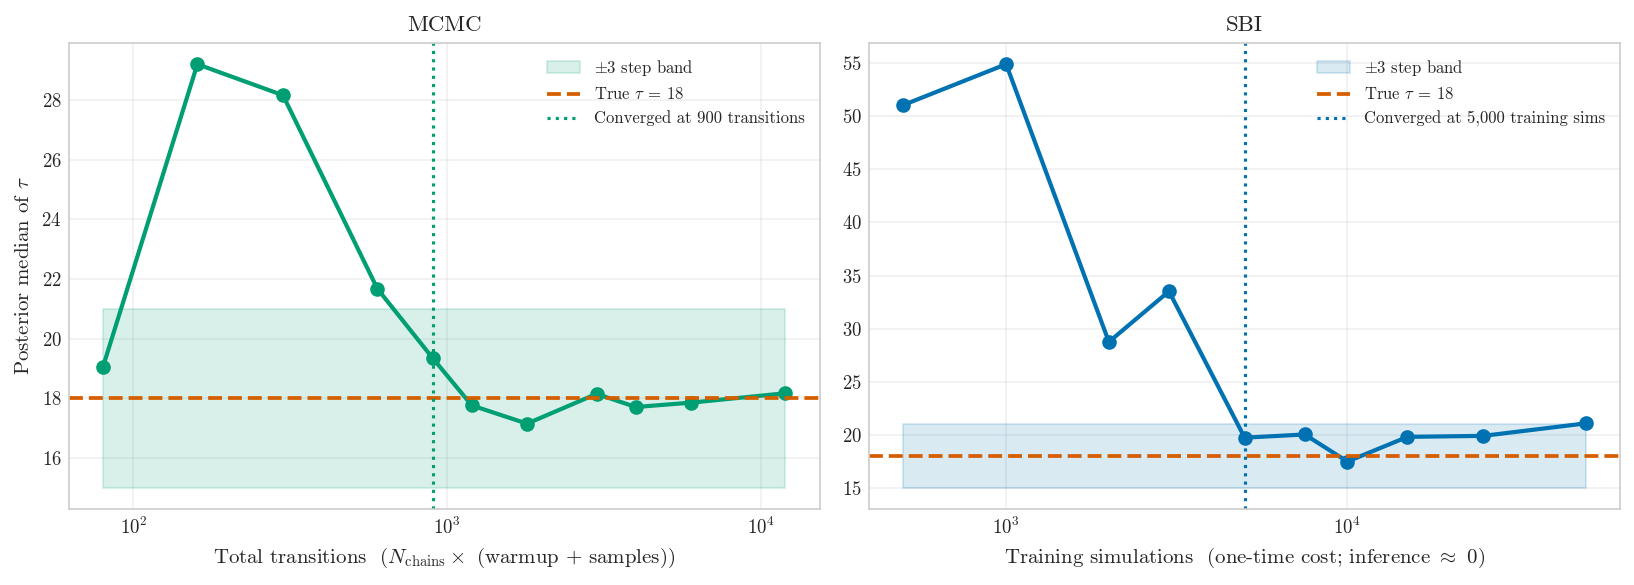

In [119]:
import matplotlib.pyplot as plt
from hx_models.style import apply_paper_style, MCMC_COLOR, SBI_COLOR, TRUE_COLOR, save_fig

apply_paper_style()

figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

CONV_TOL  = 3.0   
CONV_FRAC = 0.80  

def find_convergence_idx(values, reference, tol, frac):
    """First index j where >=frac of values[j:] are within tol of reference."""
    in_band = np.abs(values - reference) <= tol
    for j in range(len(values)):
        if in_band[j] and np.mean(in_band[j:]) >= frac:
            return j
    return len(values) - 1

# MCMC: tau median from actual re-runs at different (warmup, samples) configs
mcmc_transitions = np.array([r["total_transitions"] for r in mcmc_tau_sweep])
mcmc_tau_pts     = np.array([r["tau_median"]         for r in mcmc_tau_sweep])

mcmc_conv_idx         = find_convergence_idx(mcmc_tau_pts, TRUE_TAU, CONV_TOL, CONV_FRAC)
mcmc_conv_transitions = int(mcmc_transitions[mcmc_conv_idx])

# SBI tau median vs training simulations
sbi_n_sims   = np.array([r["n_sims"]             for r in sbi_sweep])
sbi_tau_meds = np.array([r["tau_median_rep_obs"]  for r in sbi_sweep])

sbi_conv_idx  = find_convergence_idx(sbi_tau_meds, TRUE_TAU, CONV_TOL, CONV_FRAC)
sbi_conv_sims = int(sbi_n_sims[sbi_conv_idx])

print(f"Convergence criterion: first point where >={CONV_FRAC:.0%} of remaining "
      f"estimates are within +/-{CONV_TOL} of TRUE_TAU={TRUE_TAU}")
print(f"MCMC: tau converges at {mcmc_conv_transitions:,} total transitions")
print(f"SBI:  tau converges at {sbi_conv_sims:,} training simulations")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.fill_between(mcmc_transitions,
                TRUE_TAU - CONV_TOL, TRUE_TAU + CONV_TOL,
                color=MCMC_COLOR, alpha=0.15,
                label=r"$\pm$" + f"{CONV_TOL:.0f} step band")
ax.plot(mcmc_transitions, mcmc_tau_pts, color=MCMC_COLOR, lw=2.0, marker="o", markersize=6)
ax.axhline(TRUE_TAU, color=TRUE_COLOR, ls="--", lw=1.8,
           label=r"True $\tau$ = " + f"{TRUE_TAU:.0f}")
ax.axvline(mcmc_conv_transitions, color=MCMC_COLOR, ls=":", lw=1.5,
           label=f"Converged at {mcmc_conv_transitions:,} transitions")
ax.set_xscale("log")
ax.set_xlabel(r"Total transitions  ($N_{\mathrm{chains}} \times$ (warmup + samples))")
ax.set_ylabel(r"Posterior median of $\tau$")
ax.set_title(r"MCMC")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: SBI
ax = axes[1]
ax.fill_between(sbi_n_sims,
                TRUE_TAU - CONV_TOL, TRUE_TAU + CONV_TOL,
                color=SBI_COLOR, alpha=0.15,
                label=r"$\pm$" + f"{CONV_TOL:.0f} step band")
ax.plot(sbi_n_sims, sbi_tau_meds, color=SBI_COLOR, lw=2.0, marker="o", markersize=6)
ax.axhline(TRUE_TAU, color=TRUE_COLOR, ls="--", lw=1.8,
           label=r"True $\tau$ = " + f"{TRUE_TAU:.0f}")
ax.axvline(sbi_conv_sims, color=SBI_COLOR, ls=":", lw=1.5,
           label=f"Converged at {sbi_conv_sims:,} training sims")
ax.set_xscale("log")
ax.set_xlabel(r"Training simulations  (one-time cost; inference $\approx$ 0)")
ax.set_title(r"SBI")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)


plt.tight_layout()
save_fig(fig, figures_dir / "tau_convergence_scenario2")
plt.show()


## Break-even Analysis

**Cost model** (units: simulator calls — i.e. evaluations of the physical model):

| Method | Per-inference cost | One-time cost |
|--------|--------------------|---------------|
| MCMC   | `# chains × (burnin + convergence draws)` | — |
| SBI    | ≈ 0 (neural network only) | `training simulations` |


Break-even = the number of inference calls at which MCMC cumulative cost overtakes SBI total cost.

MCMC convergence threshold:  900 total transitions per inference call
SBI  training cost:          5,000 simulator calls  (one-time)
SBI  per-inference cost:     ~0  (neural network, no simulator calls)
Break-even at:               5.6 inference calls


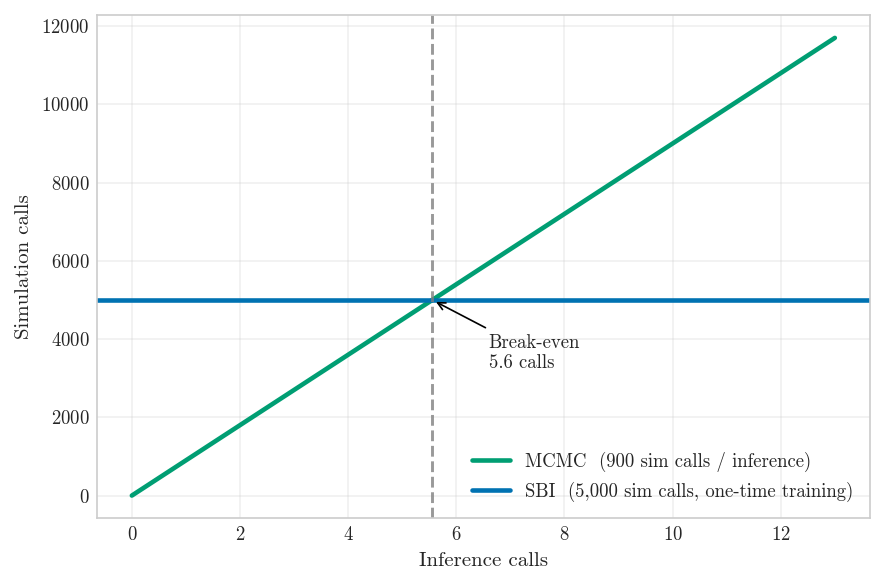

In [120]:
mcmc_per_inf      = mcmc_conv_transitions
sbi_training_cost = sbi_conv_sims
breakeven_calls   = sbi_training_cost / mcmc_per_inf

print(f"MCMC convergence threshold:  {mcmc_conv_transitions:,} total transitions per inference call")
print(f"SBI  training cost:          {sbi_training_cost:,} simulator calls  (one-time)")
print(f"SBI  per-inference cost:     ~0  (neural network, no simulator calls)")
print(f"Break-even at:               {breakeven_calls:.1f} inference calls")

fig, ax = plt.subplots(figsize=(6, 4))

n_max = int(breakeven_calls * 2.5)
n_arr = np.linspace(0, n_max, 500)
ax.plot(n_arr, n_arr * mcmc_per_inf, color=MCMC_COLOR, lw=2.2,
        label=f"MCMC  ({mcmc_per_inf:,} sim calls / inference)")
ax.axhline(sbi_training_cost, color=SBI_COLOR, lw=2.2,
           label=f"SBI  ({sbi_training_cost:,} sim calls, one-time training)")
ax.axvline(breakeven_calls, color="gray", ls="--", lw=1.4, alpha=0.8)
ax.annotate(
    f"Break-even\n{breakeven_calls:.1f} calls",
    xy=(breakeven_calls, sbi_training_cost),
    xytext=(breakeven_calls + n_max * 0.08, sbi_training_cost * 0.65),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", lw=0.8),
)
ax.set_xlabel("Inference calls")
ax.set_ylabel("Simulation calls")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, figures_dir / "breakeven_scenario2")
plt.show()


In [125]:

mcmc_cfg     = mcmc_tau_sweep[mcmc_conv_idx]
mcmc_sim_calls = mcmc_cfg["total_transitions"]
mcmc_tau_val   = mcmc_cfg["tau_median"]
mcmc_inf_time  = mcmc_cfg["time"]
mcmc_acc       = 1.0   # all configs achieve 100% (DiscreteHMCGibbs)
mcmc_desc      = (f"{NUM_CHAINS} chains, "
                  f"{mcmc_cfg['num_warmup']}W + {mcmc_cfg['num_samples']}S")


sbi_cfg      = sbi_sweep[sbi_conv_idx]
sbi_sim_calls  = sbi_cfg["n_sims"]
sbi_tau_val    = sbi_cfg["tau_median_rep_obs"]
sbi_inf_time   = sbi_cfg["mean_time"]
sbi_inf_std    = sbi_cfg["std_time"]
sbi_train_time = sbi_cfg["train_time"]
sbi_acc        = sbi_cfg["accuracy"]
sbi_desc       = f"{sbi_cfg['n_sims']:,} training simulations"

speedup = mcmc_inf_time / sbi_inf_time


c = [28, 10, 10, 12, 16, 14]
hdr = (f"{'Method':<{c[0]}} {'Sim calls':>{c[1]}} {'Accuracy':>{c[2]}} "
       f"{'tau-hat':>{c[3]}} {'Inference time':>{c[4]}} {'Training time':>{c[5]}}")
sep = "-" * sum(c)
r1 = (f"{'MCMC  ' + mcmc_desc:<{c[0]}} {mcmc_sim_calls:>{c[1]},} "
      f"{mcmc_acc:>{c[2]}.1%} {mcmc_tau_val:>{c[3]}.1f} "
      f"{mcmc_inf_time:>{c[4]-2}.1f} s{'':2} {chr(8212):>{c[5]}}")
r2 = (f"{'SBI   ' + sbi_desc:<{c[0]}} {sbi_sim_calls:>{c[1]},} "
      f"{sbi_acc:>{c[2]}.1%} {sbi_tau_val:>{c[3]}.1f} "
      f"{sbi_inf_time:>{c[4]-8}.3f} +/- {sbi_inf_std:.3f} s "
      f"{sbi_train_time:>{c[5]-2}.0f} s")


print(hdr); print(sep); print(r1); print(r2)
print(f"\nSpeedup: SBI inference is {speedup:.0f}x faster than MCMC per diagnosis.")
print(f"SBI one-time training cost: {sbi_train_time:.0f} s.")
print(f"True tau = {TRUE_TAU}, MCMC tau-hat = {mcmc_tau_val:.1f}, SBI tau-hat = {sbi_tau_val:.1f}")

# LaTeX tabular
mcmc_cfg_latex = (f"$4$ chains, ${mcmc_cfg['num_warmup']}$burnin $+$ ${mcmc_cfg['num_samples']}$convergence samples")
sbi_cfg_latex  = f"${sbi_cfg['n_sims']:,}$ training simulations"


Method                        Sim calls   Accuracy      tau-hat   Inference time  Training time
------------------------------------------------------------------------------------------
MCMC  4 chains, 150W + 75S          900     100.0%         19.4            2.4 s                —
SBI   5,000 training simulations      5,000     100.0%         19.7    0.029 +/- 0.003 s           19 s

Speedup: SBI inference is 82x faster than MCMC per diagnosis.
SBI one-time training cost: 19 s.
True tau = 18.0, MCMC tau-hat = 19.4, SBI tau-hat = 19.7
